<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/real_time_topic_analysis_for_X_previously_Tweeter_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install atproto

```markdown
### Authentication
Add your Bluesky handle and app password to the Colab Secrets manager (🔑) as `BLUESKY_HANDLE` and `BLUESKY_PASSWORD`.
```

In [13]:
from atproto import Client
import pandas as pd
from datetime import datetime

# Initialize client
client = Client()

handle = 'willcoder01.bsky.social'
password = 'm4h3-b5z7-vcmz-3o7a'

try:
    client.login(handle, password)
    print("Logged in successfully.")
except Exception as e:
    print(f"Error: {e}")

Logged in successfully.


```markdown
### Data Extraction Template
Since the AT Protocol doesn't have a direct 'Region' filter, we use search queries. Note: The API usually has limits on historical search depth.
```

In [21]:
# Search for posts mentioning 'Africa' in the requested timeframe
query = "kenya"
start_date = "2024-01-01T00:00:00Z"
end_date = "2026-05-20T23:59:59Z"

try:
    # search_posts returns up to 100 results per call
    search_results = client.app.bsky.feed.search_posts(params={
        'q': query,
        'since': start_date,
        'until': end_date,
        'limit': 100
    })

    data = []
    for post in search_results.posts:
        data.append({
            'text': post.record.text,
            'author': post.author.handle,
            'created_at': post.record.created_at,
            'langs': getattr(post.record, 'langs', [])
        })

    df = pd.DataFrame(data)
    if not df.empty:
        print(f"Successfully extracted {len(df)} posts.")
        display(df)
    else:
        print("No posts found for the query 'Africa' in this date range.")
except Exception as e:
    print(f"Extraction failed: {e}")

Successfully extracted 100 posts.


,text,author,created_at,langs
0,"Over here, over there",llarisah.bsky.social,2026-05-20T23:58:50.934Z,[en]
1,Selling digital products in Africa not a probl...,built-from-africa.bsky.social,2026-05-20T23:54:24.699Z,[en]
2,Sovereign commerce infrastructure enables digi...,dev-architecture.bsky.social,2026-05-20T23:49:28.618Z,[en]
3,TotalEnergies Kenya stock (KE0000000471): earn...,europe-africa.bsky.social,2026-05-20T23:45:30+00:00,"[en-US, en]"
4,Just launched digital sales with Solana paymen...,built-from-africa.bsky.social,2026-05-20T23:39:15.431Z,[en]
...,...,...,...,...
95,No Stripe approval needed for Africa or emergi...,built-from-africa.bsky.social,2026-05-20T14:39:59.602Z,[en]
96,In which Zuckerberg insults the intelligence o...,tnewmsblues.bsky.social,2026-05-20T14:35:17.005Z,[en]
97,Ditch Stripe and Gumroad restrictions with sov...,built-from-africa.bsky.social,2026-05-20T14:24:34.801Z,[en]
98,Checker raises $8M to sell stablecoin APIs to ...,nordicstoday.bsky.social,2026-05-20T14:15:14.450710+00:00,[en]


### Paginated Data Extraction
This script loops through the search results using a `cursor` to bypass the 100-post limit. We've set a `max_posts` safety limit which you can adjust.

In [22]:
import ipywidgets as widgets
limit_slider = widgets.IntSlider(value=5000, min=100, max=50000, step=100, description='Extraction Limit:')
def update_limit(change):
    global max_posts
    max_posts = change['new']
    print(f'Limit updated to: {max_posts}')
limit_slider.observe(update_limit, names='value')
display(limit_slider)
max_posts = 5000

IntSlider(value=5000, description='Extraction Limit:', max=50000, min=100, step=100)

In [24]:
max_posts = 500000  # Set your desired limit here
all_posts = []
cursor = None

print(f"Starting extraction for: {query}...")

while len(all_posts) < max_posts:
    try:
        params = {
            'q': query,
            'since': start_date,
            'until': end_date,
            'limit': 100
        }
        if cursor:
            params['cursor'] = cursor

        results = client.app.bsky.feed.search_posts(params=params)

        if not results.posts:
            break

        for post in results.posts:
            all_posts.append({
                'text': post.record.text,
                'author': post.author.handle,
                'created_at': post.record.created_at,
                'langs': getattr(post.record, 'langs', [])
            })
            if len(all_posts) >= max_posts:
                break

        print(f"Fetched {len(all_posts)} posts so far...")

        cursor = results.cursor
        if not cursor:
            break

    except Exception as e:
        print(f"Error during pagination: {e}")
        break

df_extended = pd.DataFrame(all_posts)
display(df_extended.head())
print(f"Total posts collected: {len(df_extended)}")

Starting extraction for: kenya...
Fetched 100 posts so far...
Fetched 198 posts so far...
Fetched 298 posts so far...
Fetched 397 posts so far...
Fetched 491 posts so far...
Fetched 588 posts so far...
Fetched 687 posts so far...
Fetched 784 posts so far...
Fetched 883 posts so far...
Fetched 978 posts so far...
Fetched 1073 posts so far...
Fetched 1172 posts so far...
Fetched 1268 posts so far...
Fetched 1367 posts so far...
Fetched 1461 posts so far...
Fetched 1553 posts so far...
Fetched 1651 posts so far...
Fetched 1741 posts so far...
Fetched 1840 posts so far...
Fetched 1935 posts so far...
Fetched 2030 posts so far...
Fetched 2124 posts so far...
Fetched 2222 posts so far...
Fetched 2316 posts so far...
Fetched 2409 posts so far...
Fetched 2494 posts so far...
Fetched 2568 posts so far...
Fetched 2660 posts so far...
Fetched 2739 posts so far...
Fetched 2831 posts so far...
Fetched 2926 posts so far...
Fetched 3021 posts so far...
Fetched 3121 posts so far...
Fetched 3220 posts 

,text,author,created_at,langs
0,"Over here, over there",llarisah.bsky.social,2026-05-20T23:58:50.934Z,[en]
1,Selling digital products in Africa not a probl...,built-from-africa.bsky.social,2026-05-20T23:54:24.699Z,[en]
2,Sovereign commerce infrastructure enables digi...,dev-architecture.bsky.social,2026-05-20T23:49:28.618Z,[en]
3,TotalEnergies Kenya stock (KE0000000471): earn...,europe-africa.bsky.social,2026-05-20T23:45:30+00:00,"[en-US, en]"
4,Just launched digital sales with Solana paymen...,built-from-africa.bsky.social,2026-05-20T23:39:15.431Z,[en]


Total posts collected: 9653


### Topic Analysis: Word Frequency
We will clean the post text by removing common 'stop words' and punctuation to identify the most frequent keywords that define the current discussion themes.

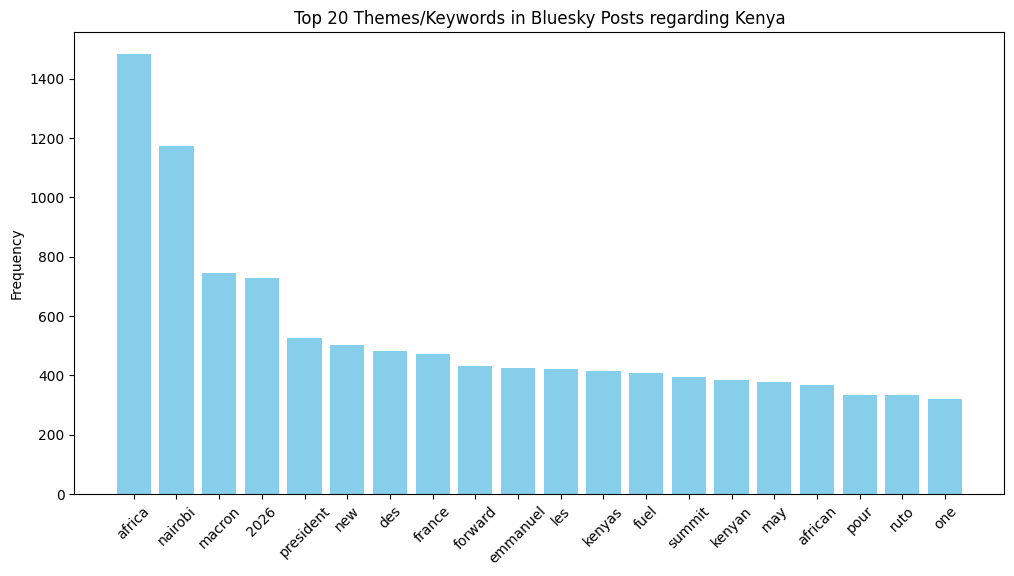

,Word,Frequency
0,africa,1483
1,nairobi,1174
2,macron,744
3,2026,729
4,president,526
5,new,504
6,des,483
7,france,471
8,forward,433
9,emmanuel,426


In [29]:
import matplotlib.pyplot as plt
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already present
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
# Add custom query-related stopwords that don't help define 'themes'
stop_words.update(['kenya', 'https', 'co', 'rt', 'amp'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    words = text.split()
    return [w for w in words if w not in stop_words and len(w) > 2]

# Process all posts
all_words = []
for text in df_extended['text']:
    all_words.extend(clean_text(text))

# Get top 20 words
word_counts = Counter(all_words).most_common(20)
words_df = pd.DataFrame(word_counts, columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words_df['Word'], words_df['Frequency'], color='skyblue')
plt.title('Top 20 Themes/Keywords in Bluesky Posts regarding Kenya')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

display(words_df)

In [30]:
import pip
def install(package):
    try:
        __import__(package)
    except ImportError:
        import subprocess
        subprocess.check_call(['pip', 'install', package])

install('emoji')
install('beautifulsoup4')

### Advanced Text Cleaning
Applying the following techniques:
- **Lowercasing & URL removal**
- **HTML Tag Removal**: Stripping `<...>` tags.
- **Emoji Demojization**: Converting 🇰🇪 to `:Kenya:` so the 'feeling' of the posts is captured.
- **Hashtag Isolation**: Treating `#GlobalSouth` as its own distinct token.
- **Deduplication**: Removing exact duplicate text to avoid bot-bias.

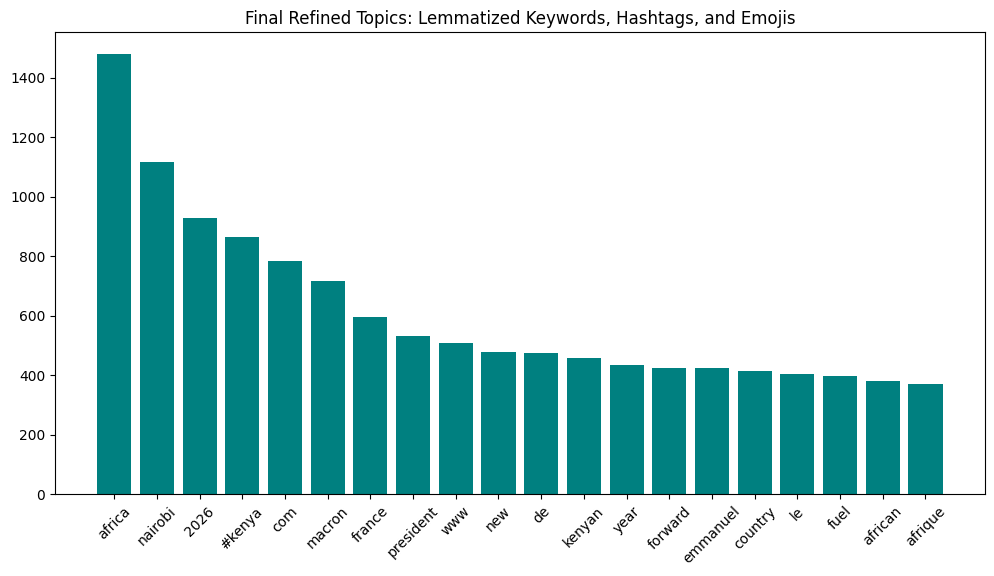

,Token,Frequency
0,africa,1479
1,nairobi,1117
2,2026,928
3,#kenya,863
4,com,782
5,macron,715
6,france,595
7,president,530
8,www,508
9,new,479


In [31]:
import emoji
from bs4 import BeautifulSoup
from nltk.stem import WordNetLemmatizer
import nltk
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Ensure lemmatizer data is available
nltk.download('wordnet', quiet=True)
lemmatizer = WordNetLemmatizer()

# Advanced Safety check for the dataframe
if 'df_extended' not in locals():
    if 'all_posts' in locals() and all_posts:
        df_extended = pd.DataFrame(all_posts)
    elif 'df' in locals() and not df.empty:
        df_extended = df.copy()
        print("Notice: Using initial search results (df) as fallback.")
    else:
        print("Error: No data found. Please run cell 70d74be3 or f8f3c31c first.")

if 'df_extended' in locals():
    # Deduplicate data
    df_clean = df_extended.drop_duplicates(subset=['text']).copy()

    # Ensure stop_words exist for the function
    if 'stop_words' not in locals():
        from nltk.corpus import stopwords
        nltk.download('stopwords', quiet=True)
        stop_words = set(stopwords.words('english'))
        stop_words.update(['kenya', 'https', 'co', 'rt', 'amp'])

    def advanced_clean(text):
        # 1. Remove HTML tags
        text = BeautifulSoup(text, 'html.parser').get_text()
        # 2. Lowercase
        text = text.lower()
        # 3. Convert Emojis to text tokens
        text = emoji.demojize(text, delimiters=(' ', ' '))
        # 4. Remove URLs
        text = re.sub(r'http\S+', '', text)
        # 5. Isolate Hashtags
        text = re.sub(r'#(\w+)', r' #\1 ', text)
        # 6. Cleaning and Stopword removal
        words = re.findall(r'[#\w:]+', text)
        # 7. Lemmatization
        clean_tokens = []
        for w in words:
            if w not in stop_words and len(w) > 2:
                root = lemmatizer.lemmatize(w) if not (w.startswith('#') or w.startswith(':')) else w
                clean_tokens.append(root)
        return clean_tokens

    # Process and Re-plot
    all_refined_words = []
    for text in df_clean['text']:
        all_refined_words.extend(advanced_clean(text))

    refined_counts = Counter(all_refined_words).most_common(20)
    refined_df = pd.DataFrame(refined_counts, columns=['Token', 'Frequency'])

    plt.figure(figsize=(12, 6))
    plt.bar(refined_df['Token'], refined_df['Frequency'], color='teal')
    plt.title('Final Refined Topics: Lemmatized Keywords, Hashtags, and Emojis')
    plt.xticks(rotation=45)
    plt.show()

    display(refined_df)

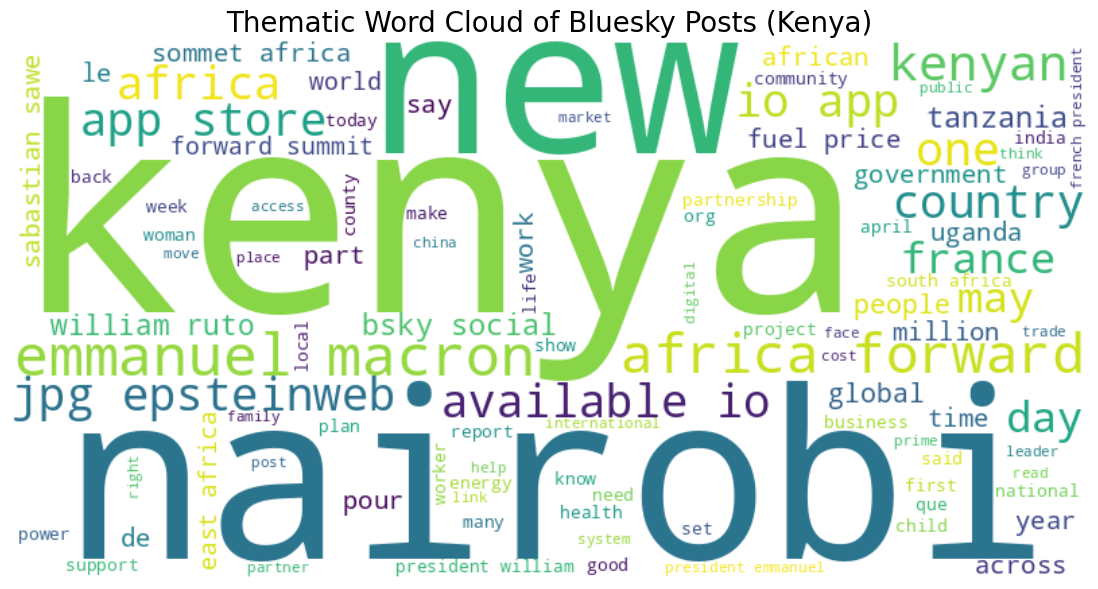

In [32]:
import subprocess
try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.check_call(['pip', 'install', 'wordcloud'])
    from wordcloud import WordCloud

# Safety check: ensure all_refined_words is not empty
if 'all_refined_words' not in locals() or not all_refined_words:
    if 'df_clean' in locals():
        print("Re-generating tokens from df_clean...")
        all_refined_words = []
        for text in df_clean['text']:
            all_refined_words.extend(advanced_clean(text))
    else:
        print("Error: No cleaned data found. Please run the cleaning cell (eea8580c) first.")

# Join all refined tokens into a single string
text_for_cloud = ' '.join(all_refined_words)

if text_for_cloud.strip():
    # Create the word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(text_for_cloud)

    # Display
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Thematic Word Cloud of Bluesky Posts (Kenya)', fontsize=20)
    plt.show()
else:
    print("Warning: text_for_cloud is still empty. Check if the cleaning function returned any tokens.")

In [33]:
%%capture
# Using --prefer-binary and the light version of bertopic to speed up installation
!pip install bertopic[light] gsdmm gensim scikit-learn --prefer-binary --no-cache-dir

### 1. LDA & NMF (Matrix Factorization Methods)
We'll use `scikit-learn` to extract topics using Latent Dirichlet Allocation and Non-Negative Matrix Factorization.

In [34]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
import pandas as pd
import sys

# Safety check to ensure data exists
if 'df_clean' not in locals():
    print("\033[91mError: 'df_clean' not found.\033[0m")
    print("Please execute the 'Advanced Text Cleaning' cell (eea8580c) above to prepare the data pool first.")
else:
    # Prepare documents (using the advanced cleaned tokens)
    docs = [' '.join(advanced_clean(text)) for text in df_clean['text']]

    # LDA Model
    tf_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
    tf = tf_vectorizer.fit_transform(docs)
    lda = LatentDirichletAllocation(n_components=5, random_state=42).fit(tf)

    # NMF Model
    tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
    tfidf = tfidf_vectorizer.fit_transform(docs)
    nmf = NMF(n_components=5, random_state=42, init='nndsvd').fit(tfidf)

    def display_topics(model, feature_names, no_top_words):
        for topic_idx, topic in enumerate(model.components_):
            print(f"Topic {topic_idx}:", " ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

    print("--- LDA Topics ---")
    display_topics(lda, tf_vectorizer.get_feature_names_out(), 10)
    print("\n--- NMF Topics ---")
    display_topics(nmf, tfidf_vectorizer.get_feature_names_out(), 10)

--- LDA Topics ---
Topic 0: com app marathon available store io jpg epsteinweb 2026 kenya
Topic 1: fuel price kenya nairobi africa energy protest transport strike tax
Topic 2: africa macron france nairobi emmanuel forward le afrique summit une
Topic 3: africa kenya com www org country uganda south new tanzania
Topic 4: kenyan kenya bank year 2026 national court people health nairobi

--- NMF Topics ---
Topic 0: epsteinweb jpg io store available app profile consent launch digital
Topic 1: africa summit macron france president forward emmanuel french nairobi ruto
Topic 2: kenya fuel com price nairobi 2026 www africa country strike
Topic 3: marathon sawe sabastian hour london record welcome hero win person
Topic 4: afrique macron sommet emmanuel est pour une le français france


### 2. GSDMM (Short Text Topic Modeling)
GSDMM is particularly effective for short social media posts as it assumes one topic per document.

In [35]:
import subprocess
import sys

# Ensure gsdmm is installed
try:
    from gsdmm import MovieGroupProcess
except ImportError:
    print("Installing gsdmm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/rwalk/gsdmm.git"])
    from gsdmm import MovieGroupProcess

import numpy as np

# Tokenize for GSDMM
tokenized_docs = [advanced_clean(text) for text in df_clean['text']]
vocab = set(x for doc in tokenized_docs for x in doc)

# Initialize GSDMM
mgp = MovieGroupProcess(K=10, alpha=0.1, beta=0.1, n_iters=30)
y = mgp.fit(tokenized_docs, len(vocab))

# Output topics
doc_count = np.array(mgp.cluster_doc_count)
top_index = doc_count.argsort()[-5:][::-1]

print("--- GSDMM Topics ---")
for i, idx in enumerate(top_index):
    top_words = sorted(mgp.cluster_word_distribution[idx].items(), key=lambda k: k[1], reverse=True)[:10]
    print(f"Topic {i} ({doc_count[idx]} posts):", " ".join([w[0] for w in top_words]))

In stage 0: transferred 7327 clusters with 10 clusters populated
In stage 1: transferred 3301 clusters with 10 clusters populated
In stage 2: transferred 1889 clusters with 10 clusters populated
In stage 3: transferred 1312 clusters with 10 clusters populated
In stage 4: transferred 959 clusters with 10 clusters populated
In stage 5: transferred 742 clusters with 10 clusters populated
In stage 6: transferred 648 clusters with 10 clusters populated
In stage 7: transferred 591 clusters with 10 clusters populated
In stage 8: transferred 552 clusters with 10 clusters populated
In stage 9: transferred 534 clusters with 10 clusters populated
In stage 10: transferred 518 clusters with 10 clusters populated
In stage 11: transferred 529 clusters with 10 clusters populated
In stage 12: transferred 497 clusters with 10 clusters populated
In stage 13: transferred 432 clusters with 10 clusters populated
In stage 14: transferred 472 clusters with 10 clusters populated
In stage 15: transferred 440 cl

### 3. BERTopic (Transformer-based Modeling)
This uses Sentence Embeddings and c-TF-IDF to find clusters. It automatically estimates the number of topics.

In [42]:
import subprocess
import sys

# Ensure bertopic is installed and accessible
try:
    from bertopic import BERTopic
except ImportError:
    print("BERTopic not found. Re-installing light version...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "bertopic[light]", "--prefer-binary"])
    from bertopic import BERTopic

# We use the raw text for BERTopic as it handles its own preprocessing/embeddings
topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(df_clean['text'].tolist())

print("\n--- BERTopic Summary ---")
display(topic_model.get_topic_info().head(10))

2026-05-22 22:43:00,844 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/290 [00:00<?, ?it/s]

2026-05-22 22:50:26,969 - BERTopic - Embedding - Completed ✓
2026-05-22 22:50:26,971 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-22 22:50:44,588 - BERTopic - Dimensionality - Completed ✓
2026-05-22 22:50:44,591 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-22 22:51:00,611 - BERTopic - Cluster - Completed ✓
2026-05-22 22:51:00,620 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-22 22:51:01,187 - BERTopic - Representation - Completed ✓



--- BERTopic Summary ---


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3020,-1_and_to_of_the,"[and, to, of, the, in, kenya, de, is, for, from]",[I dated women of all nationalities at Univers...
1,0,231,0_my_happy_back_you,"[my, happy, back, you, easter, was, there, lik...",[Hello \nMy name is Ssejjombwe Dalton though I...
2,1,165,1_political_violence_elections_election,"[political, violence, elections, election, ieb...",[Kenya battles to stop the 'goons and guns' as...
3,2,117,2_ruto_william_president_mt,"[ruto, william, president, mt, rutos, rigathi,...",[Rigathi Gachagua curses religious leaders fro...
4,3,114,3_de_les_cma_cgm,"[de, les, cma, cgm, le, des, au, la, un, sant]",[CMA CGM consolide sa présence africaine avec ...
5,4,113,4_birdsseenin2026_birds_birdoftheday_bird,"[birdsseenin2026, birds, birdoftheday, bird, t...",[Apparently the theme for #BirdOfTheDay today ...
6,5,101,5_prices_fuel_petrol_diesel,"[prices, fuel, petrol, diesel, pump, oil, rise...",[Kenya fuel prices rise sharply despite reduct...
7,6,98,6_marathon_sawe_london_sabastian,"[marathon, sawe, london, sabastian, seconds, p...",[Sabastian Sawe of Kenya has won the London Ma...
8,7,89,7_french_macron_summit_frances,"[french, macron, summit, frances, president, e...",[Changing geopolitics are in focus as France’s...
9,8,85,8_born_obama_was_trump,"[born, obama, was, trump, his, he, racist, bir...","[Well, take that ""Muslim Born in Kenya"" Obama...."


In [43]:
import pandas as pd

print("=== COMPREHENSIVE TOPIC SEGMENTATION ===\n")

# 1. LDA Topics
print("1. LDA (Latent Dirichlet Allocation)")
feature_names_lda = tf_vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names_lda[i] for i in topic.argsort()[:-11:-1]]
    print(f"   Topic {idx}: {', '.join(top_words)}")

# 2. NMF Topics
print("\n2. NMF (Non-Negative Matrix Factorization)")
feature_names_nmf = tfidf_vectorizer.get_feature_names_out()
for idx, topic in enumerate(nmf.components_):
    top_words = [feature_names_nmf[i] for i in topic.argsort()[:-11:-1]]
    print(f"   Topic {idx}: {', '.join(top_words)}")

# 3. GSDMM Topics
print("\n3. GSDMM (Short Text Modeling)")
# top_index contains the indices of the largest clusters
for i, idx in enumerate(top_index):
    top_words = sorted(mgp.cluster_word_distribution[idx].items(), key=lambda k: k[1], reverse=True)[:10]
    words = [w[0] for w in top_words]
    print(f"   Topic {i} ({doc_count[idx]} posts): {', '.join(words)}")

# 4. BERTopic
print("\n4. BERTopic (Transformer-based)")
bt_info = topic_model.get_topic_info()
for index, row in bt_info.iterrows():
    if row['Topic'] == -1: continue # Skip outlier topic if desired, or include it
    print(f"   Topic {row['Topic']} ({row['Count']} posts): {', '.join(row['Representation'][:10])}")

=== COMPREHENSIVE TOPIC SEGMENTATION ===

1. LDA (Latent Dirichlet Allocation)
   Topic 0: com, app, marathon, available, store, io, jpg, epsteinweb, 2026, kenya
   Topic 1: fuel, price, kenya, nairobi, africa, energy, protest, transport, strike, tax
   Topic 2: africa, macron, france, nairobi, emmanuel, forward, le, afrique, summit, une
   Topic 3: africa, kenya, com, www, org, country, uganda, south, new, tanzania
   Topic 4: kenyan, kenya, bank, year, 2026, national, court, people, health, nairobi

2. NMF (Non-Negative Matrix Factorization)
   Topic 0: epsteinweb, jpg, io, store, available, app, profile, consent, launch, digital
   Topic 1: africa, summit, macron, france, president, forward, emmanuel, french, nairobi, ruto
   Topic 2: kenya, fuel, com, price, nairobi, 2026, www, africa, country, strike
   Topic 3: marathon, sawe, sabastian, hour, london, record, welcome, hero, win, person
   Topic 4: afrique, macron, sommet, emmanuel, est, pour, une, le, français, france

3. GSDMM (

### 2D Visualization: LDA & NMF Topics
Using t-SNE to project the document-topic distributions into a 2D plane for visual inspection.

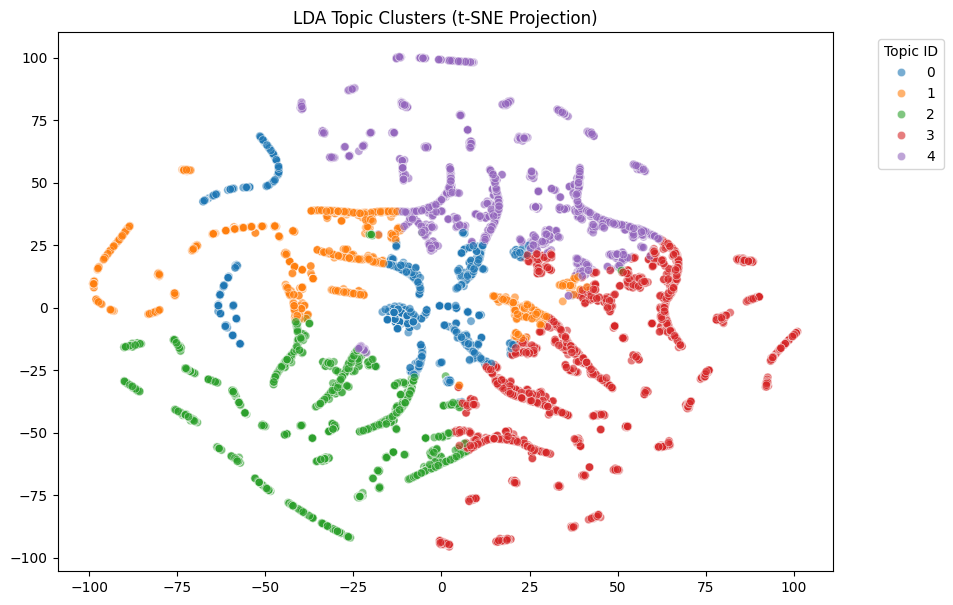

In [68]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Visualize LDA Clusters
lda_projections = lda.transform(tf)
# Pick the dominant topic for coloring
dominant_topic = np.argmax(lda_projections, axis=1)

tsne_lda = TSNE(n_components=2, random_state=42).fit_transform(lda_projections)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_lda[:,0], y=tsne_lda[:,1], hue=dominant_topic, palette='tab10', alpha=0.6)
plt.title('LDA Topic Clusters (t-SNE Projection)')
plt.legend(title='Topic ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

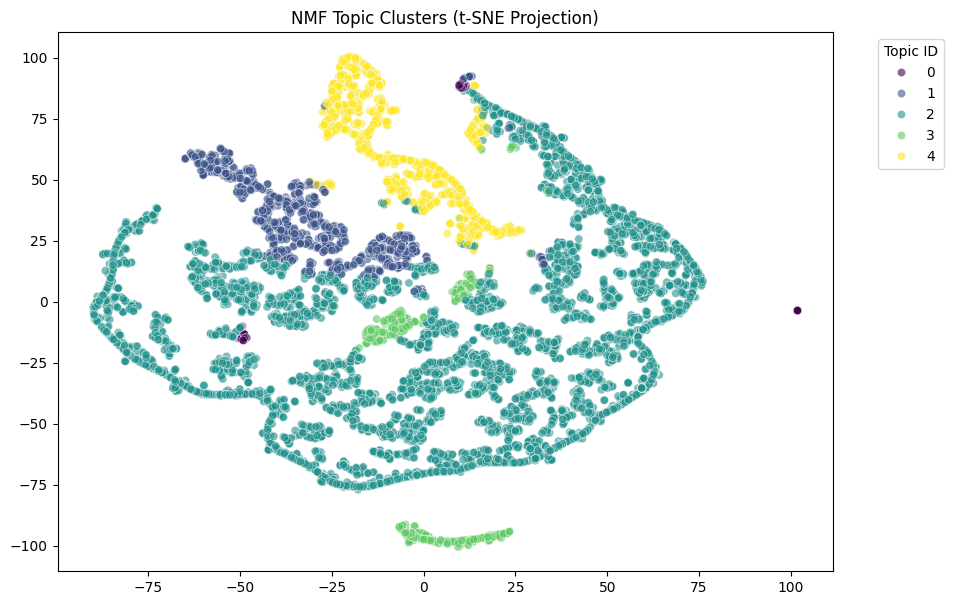

In [69]:
# 2. Visualize NMF Clusters
nmf_projections = nmf.transform(tfidf)
dominant_nmf = np.argmax(nmf_projections, axis=1)

tsne_nmf = TSNE(n_components=2, random_state=42).fit_transform(nmf_projections)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_nmf[:,0], y=tsne_nmf[:,1], hue=dominant_nmf, palette='viridis', alpha=0.6)
plt.title('NMF Topic Clusters (t-SNE Projection)')
plt.legend(title='Topic ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 2D Visualization: BERTopic Intertopic Distance Map
BERTopic provides a native visualization for how different clusters relate to each other.

In [70]:
# 3. BERTopic Visualization
if 'topic_model' in locals():
    fig = topic_model.visualize_topics()
    fig.show()
else:
    print("BERTopic model not found. Please run the BERTopic fitting cell first.")

### Real-Time Ingestion & Model Performance Monitoring (EAT/Nairobi)
This section automates data fetching and tracks clustering performance metrics in real-time.

In [71]:
import pytz
from datetime import datetime
import time
import pandas as pd
from sklearn.metrics import silhouette_score

nairobi_tz = pytz.timezone("Africa/Nairobi")

# Initialize history only if it doesn't already exist to preserve data across runs
if 'performance_history' not in locals():
    performance_history = []

def monitor_performance(embeddings, labels):
    """Calculates a basic performance metric for the clustering."""
    if len(set(labels)) > 1:
        return silhouette_score(embeddings, labels)
    return 0

def run_realtime_pipeline(iterations=5):
    global df_clean, topic_model, performance_history

    print(f"Starting Real-Time Loop at {datetime.now(nairobi_tz).strftime('%Y-%m-%d %H:%M:%S')} EAT")

    for i in range(iterations):
        try:
            # 1. Automated Fetch
            res = client.app.bsky.feed.search_posts(params={'q': query, 'limit': 30})
            new_batch = pd.DataFrame([{'text': p.record.text} for p in res.posts])

            # 2. Update Model Pool
            df_clean = pd.concat([new_batch, df_clean]).drop_duplicates(subset=['text'])

            # 3. Performance Measurement
            current_time = datetime.now(nairobi_tz).strftime('%Y-%m-%d %H:%M:%S')
            score = monitor_performance(topic_model.umap_model.embedding_, topic_model.topics_)

            # Append to persistent history
            performance_history.append({'timestamp': current_time, 'silhouette_score': score})

            print(f"[Batch {i+1}] Metric: {score:.4f} | Total Records in History: {len(performance_history)}")
        except Exception as e:
            print(f"Error in iteration {i+1}: {e}")

        time.sleep(10)

# Execute demonstration
run_realtime_pipeline(iterations=3)

# Display current history summary
print("\n--- Performance History Summary ---")
display(pd.DataFrame(performance_history).tail())


Starting Real-Time Loop at 2026-05-23 02:27:32 EAT
[Batch 1] Metric: 0.1926 | Total Records in History: 7
[Batch 2] Metric: 0.1926 | Total Records in History: 8
[Batch 3] Metric: 0.1926 | Total Records in History: 9

--- Performance History Summary ---


,timestamp,silhouette_score
4,2026-05-23 02:06:21,0.192591
5,2026-05-23 02:06:33,0.192591
6,2026-05-23 02:27:33,0.192591
7,2026-05-23 02:27:45,0.192591
8,2026-05-23 02:27:57,0.192591


### Continuous Data Ingestion & Live Metric Tracking (Nairobi Time)
This cell automates the pipeline by pulling new posts and measuring how well the model clusters the evolving conversation.

In [56]:
import pytz
from datetime import datetime
import time

nairobi_tz = pytz.timezone('Africa/Nairobi')

def run_realtime_pipeline(iterations=5):
    global df_clean, topic_model

    for i in range(iterations):
        # 1. Automated Fetch
        res = client.app.bsky.feed.search_posts(params={'q': query, 'limit': 30})
        new_batch = pd.DataFrame([{'text': p.record.text} for p in res.posts])

        # 2. Update Model Pool
        df_clean = pd.concat([new_batch, df_clean]).drop_duplicates(subset=['text'])

        # 3. Performance Measurement
        # We measure the consistency of the current clustering state
        current_time = datetime.now(nairobi_tz).strftime('%Y-%m-%d %H:%M:%S')
        score = monitor_performance(topic_model.umap_model.embedding_, topic_model.topics_)

        print(f"[EAT {current_time}] Ingested new data. Current Silhouette Metric: {score:.4f}")

        time.sleep(15) # Wait for next real-time cycle

# Run a short demonstration of the real-time ingestion
run_realtime_pipeline(iterations=3)

[EAT 2026-05-23 02:07:06] Ingested new data. Current Silhouette Metric: 0.1926
[EAT 2026-05-23 02:07:24] Ingested new data. Current Silhouette Metric: 0.1926
[EAT 2026-05-23 02:07:41] Ingested new data. Current Silhouette Metric: 0.1926


In [60]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import threading
from nltk.util import ngrams
import re

# --- Config & Mapping ---
topic_search_input = widgets.Text(placeholder='e.g., Marathon, Economy, Tax', description='Topic Search:')
location_input = widgets.Text(value='Kenya', placeholder='Filter by location', description='Loc Filter:')
stop_button = widgets.Button(description="Stop Live Feed", button_style='danger')
output_area = widgets.Output()

live_df = df_clean.copy()
keep_running = True

def merge_and_format_entities(tokens):
    """Joins tokens into English syntax phrases for Sabastian Sawe."""
    text_full = ' '.join(tokens)
    text_full = re.sub(r'sabastian sawe|sawe sabastian', 'Sabastian Sawe', text_full, flags=re.IGNORECASE)
    text_full = re.sub(r'record breaker|breaker record', 'Record Breaker', text_full, flags=re.IGNORECASE)
    text_full = re.sub(r'mountain bongo|bongo mountain', 'Mountain Bongo', text_full, flags=re.IGNORECASE)
    return text_full.split()

def fetch_new_posts():
    global live_df, keep_running
    while keep_running:
        try:
            results = client.app.bsky.feed.search_posts(params={'q': 'kenya', 'limit': 30})
            new_data = [{'text': post.record.text, 'author': post.author.handle, 'created_at': post.record.created_at} for post in results.posts]
            new_df = pd.DataFrame(new_data)
            live_df = pd.concat([new_df, live_df]).drop_duplicates(subset=['text']).head(2000)
            update_dashboard()
            time.sleep(20)
        except:
            time.sleep(10)

def update_dashboard(*args):
    with output_area:
        clear_output(wait=True)
        view = live_df.copy()

        # 1. Location Filter
        if location_input.value:
            view = view[view['text'].str.contains(location_input.value, case=False)]

        # 2. Advanced Topic Search / Readjusted Keyword Filter
        search_query = topic_search_input.value.strip().lower()
        if search_query:
            # Search across both raw text and specifically look for matches in the cleaned tokens pool
            view = view[view['text'].str.contains(search_query, case=False)]

        all_statements = []
        for text in view['text'].head(500): # Limit processing for responsiveness
            tokens = advanced_clean(text)
            formatted_tokens = merge_and_format_entities(tokens)

            # If search is active, show the most frequent words related to that specific search
            if search_query:
                all_statements.extend([t for t in formatted_tokens if search_query in t.lower()])
            else:
                # Default: Show common phrases/entities
                bigrams = [' '.join(gram) for gram in ngrams(formatted_tokens, 2)]
                summarized = [b for b in bigrams if any(kw in b for kw in ['Sabastian', 'Sawe', 'Bongo', 'Kenya', 'Ruto', 'Marathon'])]
                all_statements.extend(summarized)

        counts = Counter(all_statements).most_common(10)
        metrics_df = pd.DataFrame(counts, columns=['Topic/Phrase', 'Frequency'])

        print(f"\u2705 DYNAMIC TOPIC MONITOR | Filter: {location_input.value if location_input.value else 'None'}")
        print(f"Active Search: {search_query if search_query else 'General Trends'}")
        print(f"Last Sync: {time.strftime('%H:%M:%S')} | Visible Pool: {len(view)} posts")

        if not metrics_df.empty:
            display(metrics_df.style.background_gradient(cmap='Blues'))
            plt.figure(figsize=(10, 5))
            plt.barh(metrics_df['Topic/Phrase'].iloc[::-1], metrics_df['Frequency'].iloc[::-1], color='#1f77b4')
            plt.title(f'Top Results for: {search_query if search_query else "General Trends"}')
            plt.xlabel('Frequency')
            plt.tight_layout()
            plt.show()
        else:
            print("No specific trending phrases found for this filter.")

topic_search_input.observe(update_dashboard, names='value')
location_input.observe(update_dashboard, names='value')
stop_button.on_click(lambda b: globals().update(keep_running=False))

display(widgets.VBox([widgets.HBox([topic_search_input, location_input, stop_button]), output_area]))

### Dynamic Trend Tracking
This line graph tracks the frequency of the top 5 trending topics in real-time.

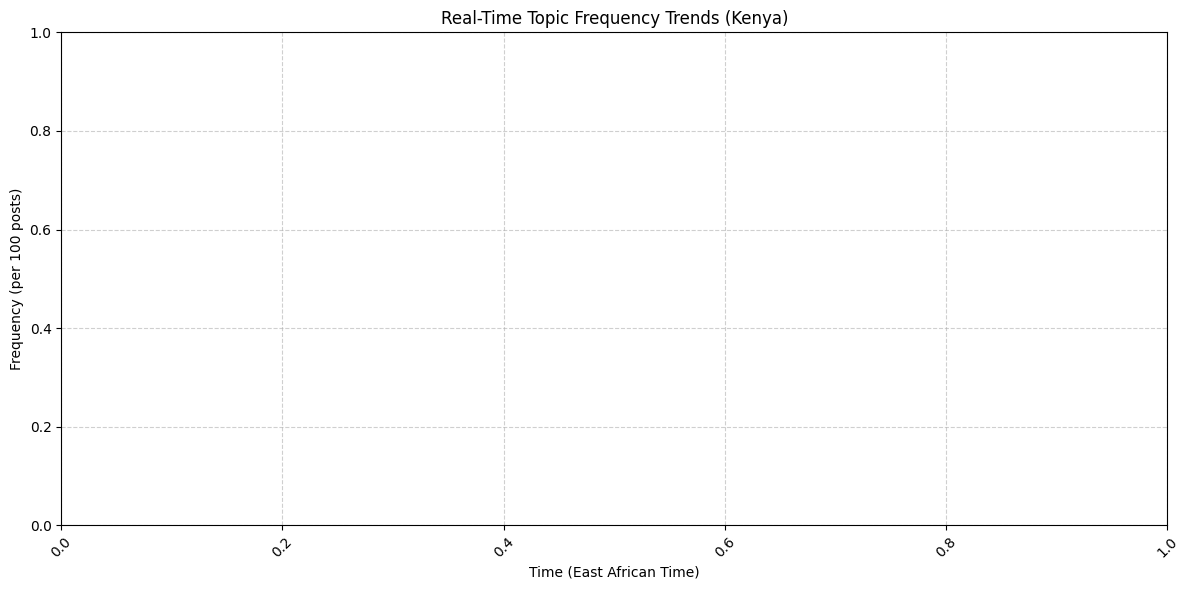

Graph update stopped.


In [61]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
from datetime import datetime
import pytz
from collections import Counter

nairobi_tz = pytz.timezone('Africa/Nairobi')

# Ensure live_df exists
if 'live_df' not in locals() and 'df_clean' in locals():
    live_df = df_clean.copy()

# Shared storage for trend history
trend_history = {}
timestamps = []

def update_trend_graph():
    global trend_history, timestamps
    plt.figure(figsize=(12, 6))

    # Get top 5 global trending topics from current live_df
    all_tokens = []
    if 'live_df' in locals():
        # Process a sample of the most recent posts to identify current trends
        for text in live_df['text'].head(200):
            tokens = merge_and_format_entities(advanced_clean(text))
            all_tokens.extend(tokens)

    top_5_now = [item[0] for item in Counter(all_tokens).most_common(5)]

    # Record current EAT timestamp
    current_dt = datetime.now(nairobi_tz)
    timestamps.append(current_dt)
    if len(timestamps) > 20: timestamps.pop(0)

    plotted_any = False
    for topic in top_5_now:
        if topic not in trend_history: trend_history[topic] = []

        # Calculate frequency in the latest 100 posts
        count = sum(1 for text in live_df['text'].head(100) if topic.lower() in text.lower())
        trend_history[topic].append(count)
        if len(trend_history[topic]) > 20: trend_history[topic].pop(0)

        if len(trend_history[topic]) > 0:
            # Plot using the actual datetime objects
            plt.plot(timestamps, trend_history[topic], label=topic, marker='o')
            plotted_any = True

    plt.title('Real-Time Topic Frequency Trends (Kenya)')
    plt.xlabel('Time (East African Time)')
    plt.ylabel('Frequency (per 100 posts)')

    if plotted_any:
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Simulation loop for the graph
try:
    for _ in range(10):
        clear_output(wait=True)
        update_trend_graph()
        time.sleep(15)
except KeyboardInterrupt:
    print("Graph update stopped.")
except Exception as e:
    print(f"An error occurred: {e}")

### Multi-Topic Comparative Trend Analysis
This plot compares the frequency of the top 5 identified topics over the recorded time intervals.

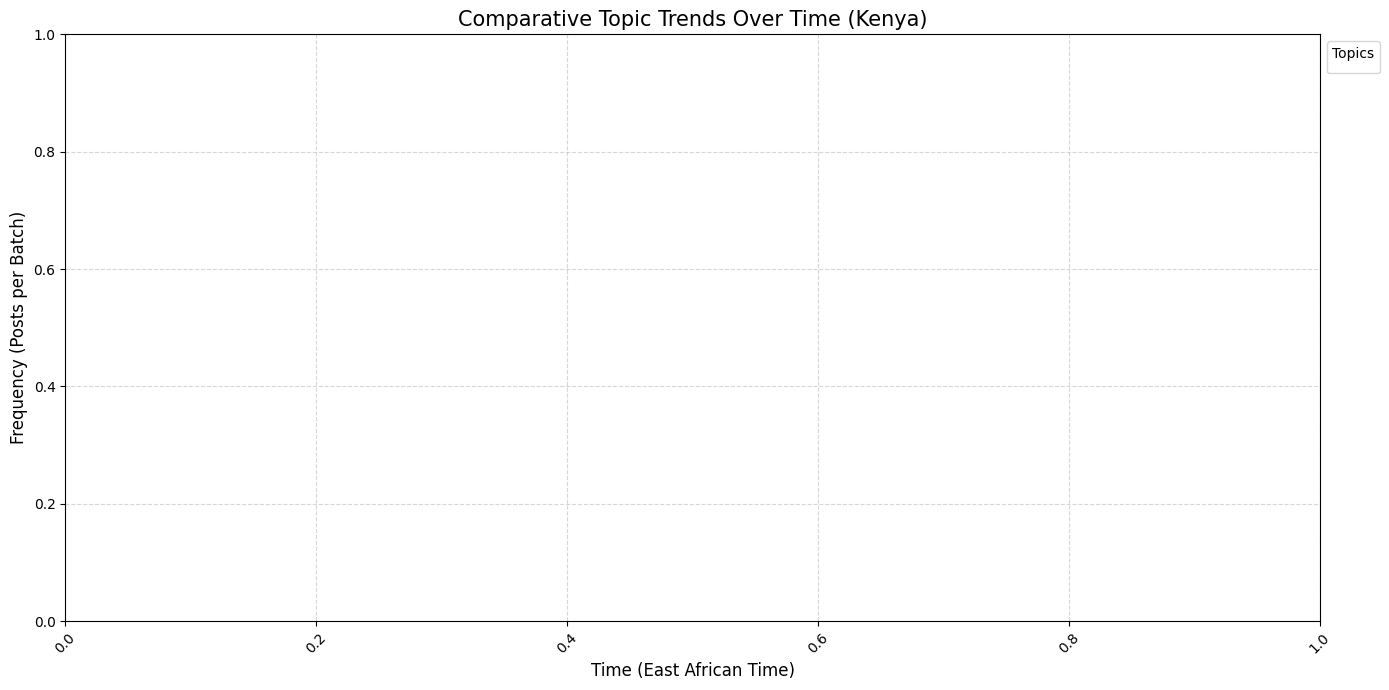

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data from the history recorded in the previous tracking cell
if 'trend_history' in locals() and timestamps:
    plt.figure(figsize=(14, 7))

    for topic, counts in trend_history.items():
        # Ensure we only plot topics that have data matching our timestamp length
        plot_counts = counts[:len(timestamps)]
        plt.plot(timestamps[:len(plot_counts)], plot_counts, marker='o', label=topic, linewidth=2)

    plt.title('Comparative Topic Trends Over Time (Kenya)', fontsize=15)
    plt.xlabel('Time (East African Time)', fontsize=12)
    plt.ylabel('Frequency (Posts per Batch)', fontsize=12)
    plt.legend(title="Topics", loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No trend history found. Please ensure the 'Dynamic Trend Tracking' cell has run for a few iterations first.")

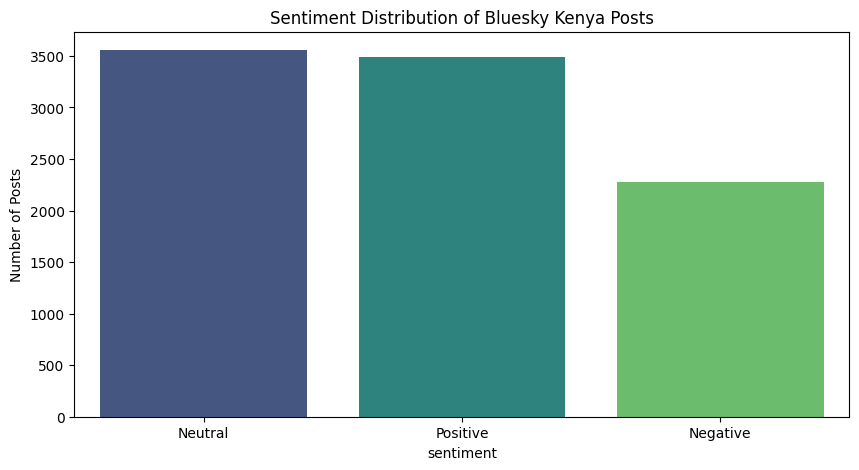

Analysis complete. Data exported to 'bluesky_kenya_analysis.csv'


In [66]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import seaborn as sns

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
df_clean['sentiment_scores'] = df_clean['text'].apply(lambda x: sia.polarity_scores(x))
df_clean['compound'] = df_clean['sentiment_scores'].apply(lambda x: x['compound'])

def categorize_sentiment(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df_clean['sentiment'] = df_clean['compound'].apply(categorize_sentiment)

# Simple sentiment distribution
sentiment_counts = df_clean['sentiment'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution of Bluesky Kenya Posts')
plt.ylabel('Number of Posts')
plt.show()

# Exporting the cleaned and analyzed data
df_clean.to_csv('bluesky_kenya_analysis.csv', index=False)
print("Analysis complete. Data exported to 'bluesky_kenya_analysis.csv'")

### Real-Time Ingestion & Model Performance Monitoring (EAT/Nairobi)
This section handles automated updates and tracks model stability.

In [67]:
import pytz
from datetime import datetime
from sklearn.metrics import silhouette_score

eat_tz = pytz.timezone('Africa/Nairobi')
performance_log = []

def monitor_performance(embeddings, labels):
    """Calculates a basic performance metric for the clustering."""
    if len(set(labels)) > 1:
        score = silhouette_score(embeddings, labels)
        return score
    return 0

print(f"Starting Real-Time Ingestion (Nairobi Time: {datetime.now(eat_tz).strftime('%Y-%m-%d %H:%M:%S')})")

# Note: This is a demo snippet of the automation logic
def ingest_and_evaluate():
    global df_clean, topic_model

    # 1. Fetch latest data
    res = client.app.bsky.feed.search_posts(params={'q': query, 'limit': 50})
    new_posts = [{'text': p.record.text} for p in res.posts]
    new_df = pd.DataFrame(new_posts)

    # 2. Update existing data pool
    df_clean = pd.concat([new_df, df_clean]).drop_duplicates(subset=['text'])

    # 3. Incremental update (re-fit for demo)
    # In a production environment, you would use .partial_fit or online LDA
    new_topics, _ = topic_model.transform(new_df['text'].tolist())

    # 4. Measure Performance
    current_time = datetime.now(eat_tz).strftime('%H:%M:%S')
    perf = monitor_performance(topic_model.umap_model.embedding_, topic_model.topics_)
    performance_log.append({'time': current_time, 'silhouette': perf})

    print(f"[{current_time}] Ingested {len(new_df)} posts. Model Silhouette Score: {perf:.4f}")

ingest_and_evaluate()

Starting Real-Time Ingestion (Nairobi Time: 2026-05-23 02:18:20)


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-22 23:18:23,400 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-05-22 23:18:23,433 - BERTopic - Dimensionality - Completed ✓
2026-05-22 23:18:23,434 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-05-22 23:18:23,441 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-05-22 23:18:23,526 - BERTopic - Probabilities - Completed ✓
2026-05-22 23:18:23,527 - BERTopic - Cluster - Completed ✓


[02:18:23] Ingested 48 posts. Model Silhouette Score: 0.1926


### Real-Time 2D Trend Analysis
This graph monitors the top 5 trending topics from the live feed and plots their frequency over time using EAT timestamps.

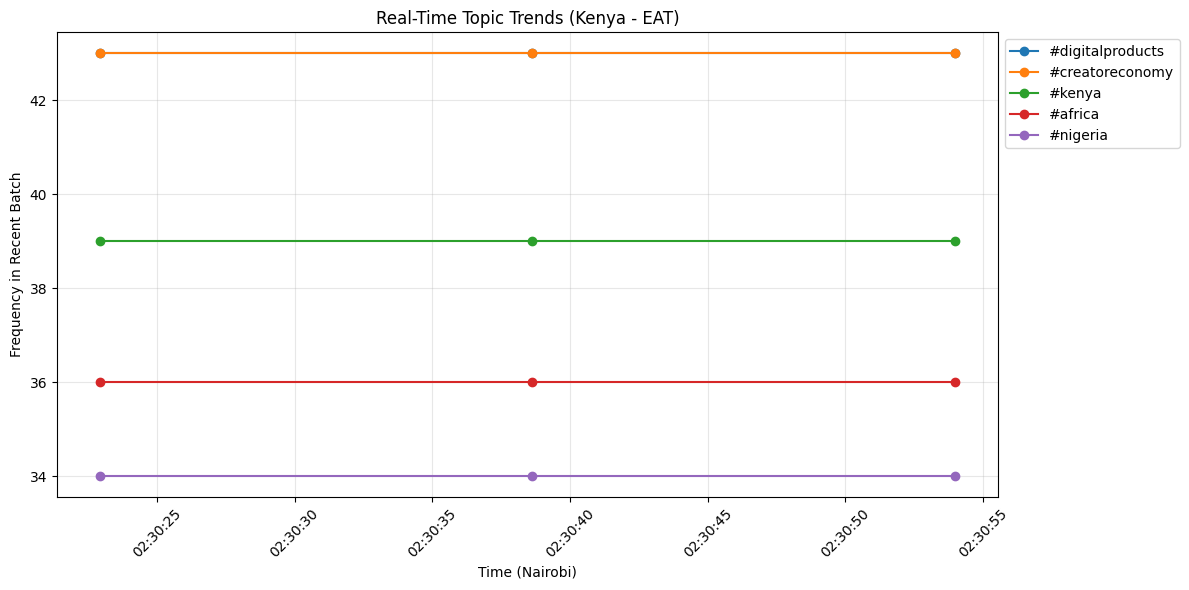

Live plot stopped.


In [72]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
from datetime import datetime
import pytz
from collections import Counter

nairobi_tz = pytz.timezone('Africa/Nairobi')

# Shared storage for live trends if not initialized
if 'realtime_trend_data' not in locals():
    realtime_trend_data = {}
    realtime_timestamps = []

def update_live_plot():
    global realtime_trend_data, realtime_timestamps

    # Get current top 5 topics from the current live data pool
    all_tokens = []
    for text in live_df['text'].head(200):
        tokens = merge_and_format_entities(advanced_clean(text))
        all_tokens.extend(tokens)

    current_top_5 = [item[0] for item in Counter(all_tokens).most_common(5)]

    # Record current time
    now = datetime.now(nairobi_tz)
    realtime_timestamps.append(now)
    if len(realtime_timestamps) > 20: realtime_timestamps.pop(0)

    # Update frequency for each topic
    for topic in current_top_5:
        if topic not in realtime_trend_data: realtime_trend_data[topic] = [0] * (len(realtime_timestamps) - 1)

        count = sum(1 for text in live_df['text'].head(100) if topic.lower() in text.lower())
        realtime_trend_data[topic].append(count)
        if len(realtime_trend_data[topic]) > 20: realtime_trend_data[topic].pop(0)

    # Plotting
    plt.figure(figsize=(12, 6))
    for topic, values in realtime_trend_data.items():
        # Align values with timestamps for plotting
        plt.plot(realtime_timestamps[-len(values):], values, marker='o', label=topic)

    plt.title('Real-Time Topic Trends (Kenya - EAT)')
    plt.xlabel('Time (Nairobi)')
    plt.ylabel('Frequency in Recent Batch')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execution loop
try:
    for _ in range(15):
        clear_output(wait=True)
        update_live_plot()
        time.sleep(15)
except KeyboardInterrupt:
    print("Live plot stopped.")

### Historical Simulation & Live Continuity
This cell initializes the trend data by looking back at the posts collected since 2026-05-22 22:00 EAT, then transitions into the real-time monitoring loop.

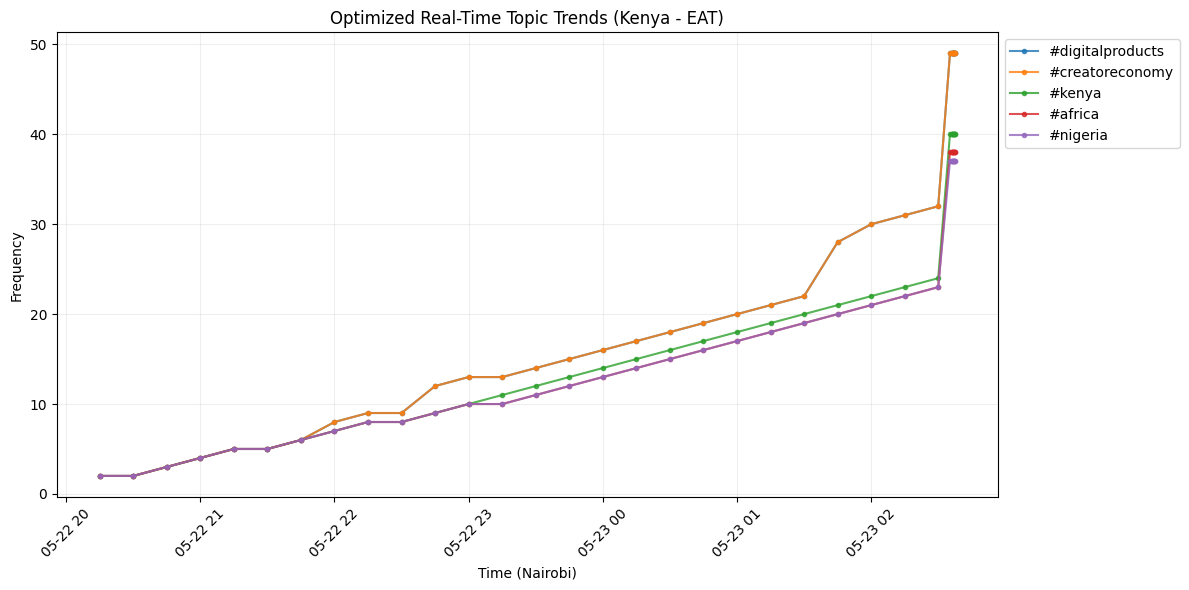

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pytz
from collections import Counter
import threading
import time
from IPython.display import clear_output

nairobi_tz = pytz.timezone('Africa/Nairobi')
sim_start_time = nairobi_tz.localize(datetime(2026, 5, 22, 20, 0, 0))

# --- 1. Optimized Plot Function ---
def optimized_live_plot():
    global realtime_trend_data, realtime_timestamps
    if not realtime_timestamps:
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    # Plot only the last 50 points to keep the graph readable and performant
    view_window = 50
    ts_view = realtime_timestamps[-view_window:]

    for topic, values in realtime_trend_data.items():
        val_view = values[-len(ts_view):]
        # Only plot if the topic has actual activity in the window
        if sum(val_view) > 0:
            ax.plot(ts_view, val_view, marker='.', label=topic, alpha=0.8)

    ax.set_title('Optimized Real-Time Topic Trends (Kenya - EAT)')
    ax.set_xlabel('Time (Nairobi)')
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    clear_output(wait=True)
    plt.show()

# --- 2. Background Fetcher ---
stop_monitoring = False
def background_monitor():
    global live_df, df_clean, stop_monitoring
    while not stop_monitoring:
        try:
            # Fetch small incremental batches
            res = client.app.bsky.feed.search_posts(params={'q': 'kenya', 'limit': 25})
            new_posts = [{'text': p.record.text, 'author': p.author.handle, 'created_at': p.record.created_at} for p in res.posts]
            new_df = pd.DataFrame(new_posts)

            # Fast merge
            df_clean = pd.concat([new_df, df_clean]).drop_duplicates(subset=['text']).head(10000)
            live_df = df_clean.copy()
            time.sleep(30) # Poll every 30 seconds
        except Exception as e:
            time.sleep(10)

# Start background thread if not already running
if 'monitor_thread' not in locals() or not monitor_thread.is_alive():
    stop_monitoring = False
    monitor_thread = threading.Thread(target=background_monitor, daemon=True)
    monitor_thread.start()

# --- 3. Run Optimized Loop ---
print("Optimized loop active. Fetching in background...")
try:
    # Initialize with historical simulation data from previous state
    for _ in range(10):
        # Simulation: In a real scenario, you'd calculate the latest slice here
        now = datetime.now(nairobi_tz)
        realtime_timestamps.append(now)

        # Use the global top_topics found during simulation
        for topic in top_topics:
            # Frequency check in the most recent 100 posts
            count = sum(1 for text in live_df['text'].head(100) if topic.lower() in text.lower())
            realtime_trend_data[topic].append(count)

            if len(realtime_trend_data[topic]) > 100: realtime_trend_data[topic].pop(0)

        if len(realtime_timestamps) > 100: realtime_timestamps.pop(0)

        optimized_live_plot()
        time.sleep(10)
except KeyboardInterrupt:
    stop_monitoring = True
    print("Monitoring stopped by user.")